In [1]:
import os
import math
import json
import warnings
import itertools
from datetime import datetime
warnings.filterwarnings("ignore")

In [2]:
os.environ.setdefault("FINTORCH_BASE_TIME_FRAME", "60")

'60'

In [162]:
import numpy as np 
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.preprocess import remove_price_dependency
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot, draw_labels, draw_predictions

In [4]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
    "--time-frame", "60",
    "--symbol", "BTC-USDT"
]

args = DefaultArgumentParser.parse(args=string_args)

In [316]:
sdf = ONLINE_EXCHANGE.future.data.update_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame).copy()

sdf = sdf[-240:-60]

sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1712177220,65631.7,65645.2,65600.0,65616.1,85.508,1393
1712177280,65616.1,65669.9,65616.1,65654.9,95.313,1396
1712177340,65654.9,65670.8,65650.6,65650.7,41.903,767
1712177400,65650.7,65655.6,65611.1,65620.0,52.627,1157
1712177460,65620.1,65629.3,65600.0,65604.7,55.612,1335
...,...,...,...,...,...,...
1712187720,66117.4,66118.2,66111.7,66118.1,27.538,598
1712187780,66118.1,66123.3,66118.1,66123.3,15.646,588
1712187840,66123.2,66174.6,66123.2,66167.0,46.358,1014


In [343]:
LOOKAHEAD = 10

df = sdf.copy()
df = remove_price_dependency(df=df)
df = np.round(df, 6)

df["fmax"] = df.high.rolling(window=LOOKAHEAD).max().shift(-WINDOW)
df["fmin"] = df.low.rolling(window=LOOKAHEAD).min().shift(-WINDOW)
df["tp"] = df.fmax - df.close
df["sl"] = df.close - df.fmin
df["profit"] = df.tp
df = df.dropna()

df

,open,high,low,close,volume,trade,fmax,fmin,tp,sl,profit
timestamp,,,,,,,,,,,
1712177280,-0.000238,0.000582,-0.000238,0.000354,95.313,1396,0.002148,-0.000484,0.001794,0.000838,0.001794
1712177340,0.000354,0.000596,0.000288,0.000290,41.903,767,0.002148,-0.000484,0.001858,0.000774,0.001858
1712177400,0.000290,0.000364,-0.000314,-0.000178,52.627,1157,0.002148,-0.000484,0.002326,0.000306,0.002326
1712177460,-0.000178,-0.000038,-0.000484,-0.000413,55.612,1335,0.002148,-0.000413,0.002561,0.000000,0.002561
1712177520,-0.000413,0.000773,-0.000413,0.000773,92.722,1322,0.002148,0.000083,0.001375,0.000690,0.001375
...,...,...,...,...,...,...,...,...,...,...,...
1712187120,0.007781,0.007914,0.007528,0.007528,58.713,1127,0.008200,0.006299,0.000672,0.001229,0.000672
1712187180,0.007528,0.007785,0.007528,0.007784,25.760,566,0.008200,0.006299,0.000416,0.001485,0.000416
1712187240,0.007784,0.007807,0.007550,0.007807,32.781,667,0.008200,0.006299,0.000393,0.001508,0.000393


In [349]:
results, best_result = {}, None

slope_values = list(np.arange(-100, 101) / 10 ** 6)
intercept_values = list(np.arange(-100, 101) / 10 ** 5)
items = list(itertools.product(slope_values, intercept_values))
bar = tqdm(items)
for slope, intercept in bar:
    df["line"] = range(len(df)) * slope + intercept
    df["above"] = 5 <= (df.line < df.low).rolling(10).sum().shift(1)
    df["touch"] = (df.low < df.line) & (df.line < df.high)
    df["buy"] = df.above & df.touch

    result = round(df[df.buy].profit.sum(), 5)
    results[(slope, intercept)] = result
    best_result = result if best_result is None else max(best_result, result)

    bar.set_postfix_str(f"best: {best_result}")

  0%|          | 0/40401 [00:00<?, ?it/s]

In [350]:
sorted_results = {k: v for k, v in sorted(results.items(), key=lambda item: item[1], reverse=True)}
best_values = list(sorted_results.keys())[0]
slope, intercept = best_values

list(sorted_results.items())[:10]

[((6.4e-05, -0.00073), 0.02878),
 ((6.4e-05, -0.00072), 0.02878),
 ((6.4e-05, -0.00071), 0.02878),
 ((6.6e-05, -0.0008), 0.02847),
 ((6.6e-05, -0.00079), 0.02847),
 ((6.6e-05, -0.00078), 0.02847),
 ((6.6e-05, -0.00077), 0.02847),
 ((6.6e-05, -0.00082), 0.02833),
 ((6.6e-05, -0.00081), 0.02833),
 ((6.5e-05, -0.00086), 0.02808)]

In [351]:
df["line"] = range(len(df)) * slope + intercept
df["above"] = 5 <= (df.line < df.low).rolling(10).sum().shift(1)
df["touch"] = (df.low < df.line) & (df.line < df.high)
df["buy"] = df.above & df.touch

df

,open,high,low,close,volume,trade,fmax,fmin,tp,sl,profit,line,above,touch,buy
timestamp,,,,,,,,,,,,,,,
1712177280,-0.000238,0.000582,-0.000238,0.000354,95.313,1396,0.002148,-0.000484,0.001794,0.000838,0.001794,-0.000730,False,False,False
1712177340,0.000354,0.000596,0.000288,0.000290,41.903,767,0.002148,-0.000484,0.001858,0.000774,0.001858,-0.000666,False,False,False
1712177400,0.000290,0.000364,-0.000314,-0.000178,52.627,1157,0.002148,-0.000484,0.002326,0.000306,0.002326,-0.000602,False,False,False
1712177460,-0.000178,-0.000038,-0.000484,-0.000413,55.612,1335,0.002148,-0.000413,0.002561,0.000000,0.002561,-0.000538,False,False,False
1712177520,-0.000413,0.000773,-0.000413,0.000773,92.722,1322,0.002148,0.000083,0.001375,0.000690,0.001375,-0.000474,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712187120,0.007781,0.007914,0.007528,0.007528,58.713,1127,0.008200,0.006299,0.000672,0.001229,0.000672,0.009766,False,False,False
1712187180,0.007528,0.007785,0.007528,0.007784,25.760,566,0.008200,0.006299,0.000416,0.001485,0.000416,0.009830,False,False,False
1712187240,0.007784,0.007807,0.007550,0.007807,32.781,667,0.008200,0.006299,0.000393,0.001508,0.000393,0.009894,False,False,False


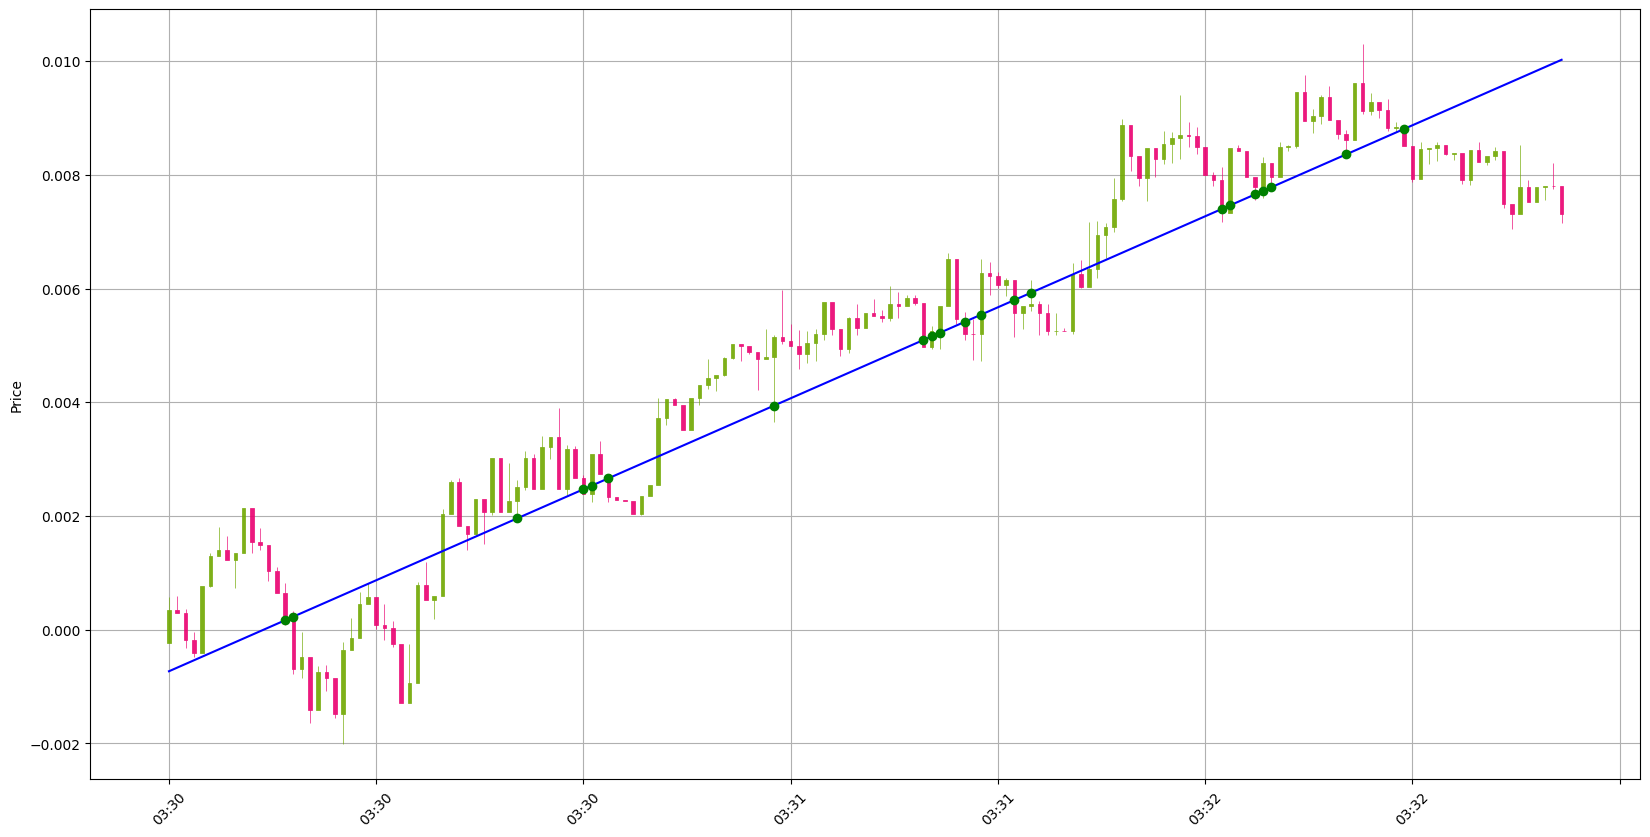

In [352]:
pdf = df.copy()
pdf = pdf.reset_index(drop=True)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
ax.grid()

draw_candlestick_plot(ax=ax, df=pdf)
ax.plot(pdf.line, "b")
ax.plot(pdf.line[pdf.buy], "go")